In [21]:
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [13]:
# Load test cases from public_cases.json
def load_cases_from_json(filename='public_cases.json'):
    """Load test cases from JSON file."""
    with open(filename, 'r') as f:
        data = json.load(f)
    
    cases = []
    for case in data:
        input_data = case['input']
        expected_output = case['expected_output']
        cases.append((
            input_data['trip_duration_days'],
            input_data['miles_traveled'],
            input_data['total_receipts_amount'],
            expected_output
        ))
    return cases


In [14]:
df = load_cases_from_json()

In [16]:
# Convert the loaded cases to a pandas DataFrame
import pandas as pd

df = pd.DataFrame(df, columns=['trip_duration_days', 'miles_traveled', 'total_receipts_amount', 'expected_output'])
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())


Dataset shape: (1000, 4)

First few rows:
   trip_duration_days  miles_traveled  total_receipts_amount  expected_output
0                   3            93.0                   1.42           364.51
1                   1            55.0                   3.60           126.06
2                   1            47.0                  17.97           128.91
3                   2            13.0                   4.67           203.52
4                   3            88.0                   5.78           380.37

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_duration_days     1000 non-null   int64  
 1   miles_traveled         1000 non-null   float64
 2   total_receipts_amount  1000 non-null   float64
 3   expected_output        1000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None

B

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [47]:
# Create a decision tree model to understand the reimbursement patterns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Prepare the features and target
X = df[['trip_duration_days', 'miles_traveled', 'total_receipts_amount']]
y = df['expected_output']

# Split the data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0, random_state=42)
# Use all data for training (no test split)
X_train, y_train = X, y


# # Create and train the decision tree
# # R2 = 1
# dt_model = DecisionTreeRegressor(
#     max_depth=20,  # Limit depth to avoid overfitting
#     min_samples_split=2,  # Require at least 20 samples to split
#     min_samples_leaf=1,   # Require at least 10 samples in each leaf
#     random_state=42
# )


# Create and train the decision tree
dt_model = DecisionTreeRegressor(
    max_depth=16,  # Limit depth to avoid overfitting
    min_samples_split=2,  # Require at least 20 samples to split
    min_samples_leaf=2,   # Require at least 10 samples in each leaf
    random_state=42
)

dt_model.fit(X_train, y_train)

# Make predictions
y_pred_train = dt_model.predict(X_train)
# y_pred_test = dt_model.predict(X_test)

# Calculate performance metrics
train_r2 = r2_score(y_train, y_pred_train)
# test_r2 = r2_score(y_test, y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
# test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("=== Decision Tree Model Performance ===")
print(f"Training R²: {train_r2:.4f}")
# print(f"Test R²: {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.2f}")
# print(f"Test RMSE: {test_rmse:.2f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

=== Decision Tree Model Performance ===
Training R²: 0.9794
Training RMSE: 67.54

=== Feature Importance ===
                 feature  importance
2  total_receipts_amount    0.653325
0     trip_duration_days    0.205674
1         miles_traveled    0.141001


In [51]:
# Create a grid search to find the optimal parameters for the decision tree model
from sklearn.model_selection import ParameterGrid

# Define parameter grid for decision tree
param_grid = {
    'max_depth': [10, 11, 12, 13, 14, 15],
    'min_samples_split': [5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [5, 6, 7, 8, 9, 10],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize variables to track best performance
best_r2 = -float('inf')
best_params = None
best_model = None

print("Searching for optimal decision tree parameters...")

# Iterate through all parameter combinations
for params in ParameterGrid(param_grid):
    # Create decision tree with current parameters
    dt_temp = DecisionTreeRegressor(random_state=42, **params)
    
    # Fit the model
    dt_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = dt_temp.predict(X_train)
    
    # Calculate R²
    r2_temp = r2_score(y_train, y_pred_temp)
    
    # Update best if current is better
    if r2_temp > best_r2:
        best_r2 = r2_temp
        best_params = params
        best_model = dt_temp

# Print best parameters and score
print("\n=== Grid Search Results ===")
print(f"Best parameters: {best_params}")
print(f"Best R²: {best_r2:.4f}")

# Use the best model as optimized model
dt_optimized = best_model

# Make predictions with optimized model
y_pred_optimized = dt_optimized.predict(X_train)

# Calculate performance metrics for optimized model
optimized_r2 = r2_score(y_train, y_pred_optimized)
optimized_rmse = np.sqrt(mean_squared_error(y_train, y_pred_optimized))

print(f"\n=== Optimized Decision Tree Performance ===")
print(f"Training R²: {optimized_r2:.4f}")
print(f"Training RMSE: {optimized_rmse:.2f}")

# Compare with original model
print(f"\n=== Performance Comparison ===")
print(f"Original model R²: {train_r2:.4f}")
print(f"Optimized model R²: {optimized_r2:.4f}")
print(f"Improvement: {optimized_r2 - train_r2:.4f}")

Searching for optimal decision tree parameters...

=== Grid Search Results ===
Best parameters: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best R²: 0.9515

=== Optimized Decision Tree Performance ===
Training R²: 0.9515
Training RMSE: 103.55

=== Performance Comparison ===
Original model R²: 0.9794
Optimized model R²: 0.9515
Improvement: -0.0279


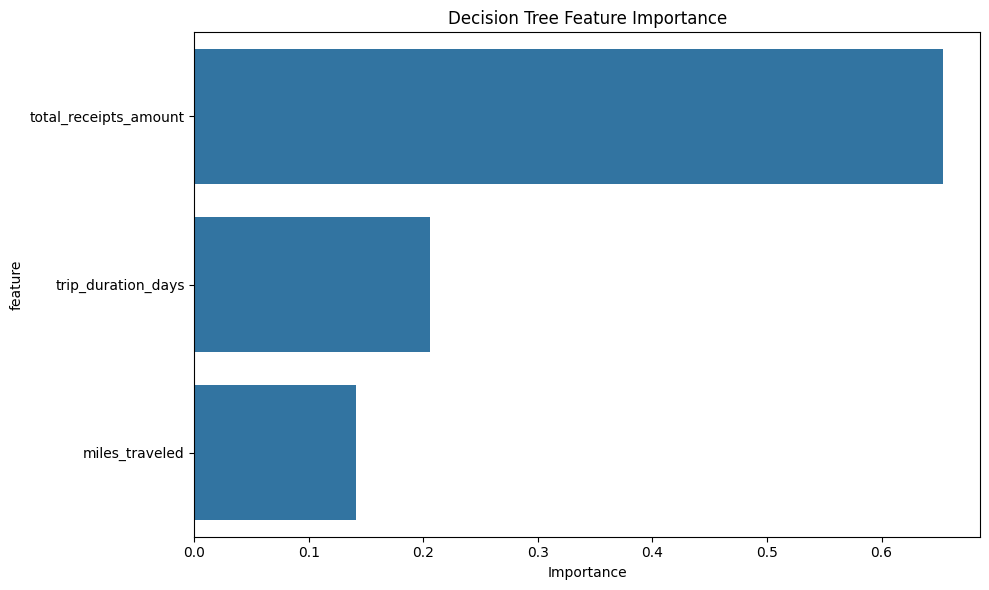

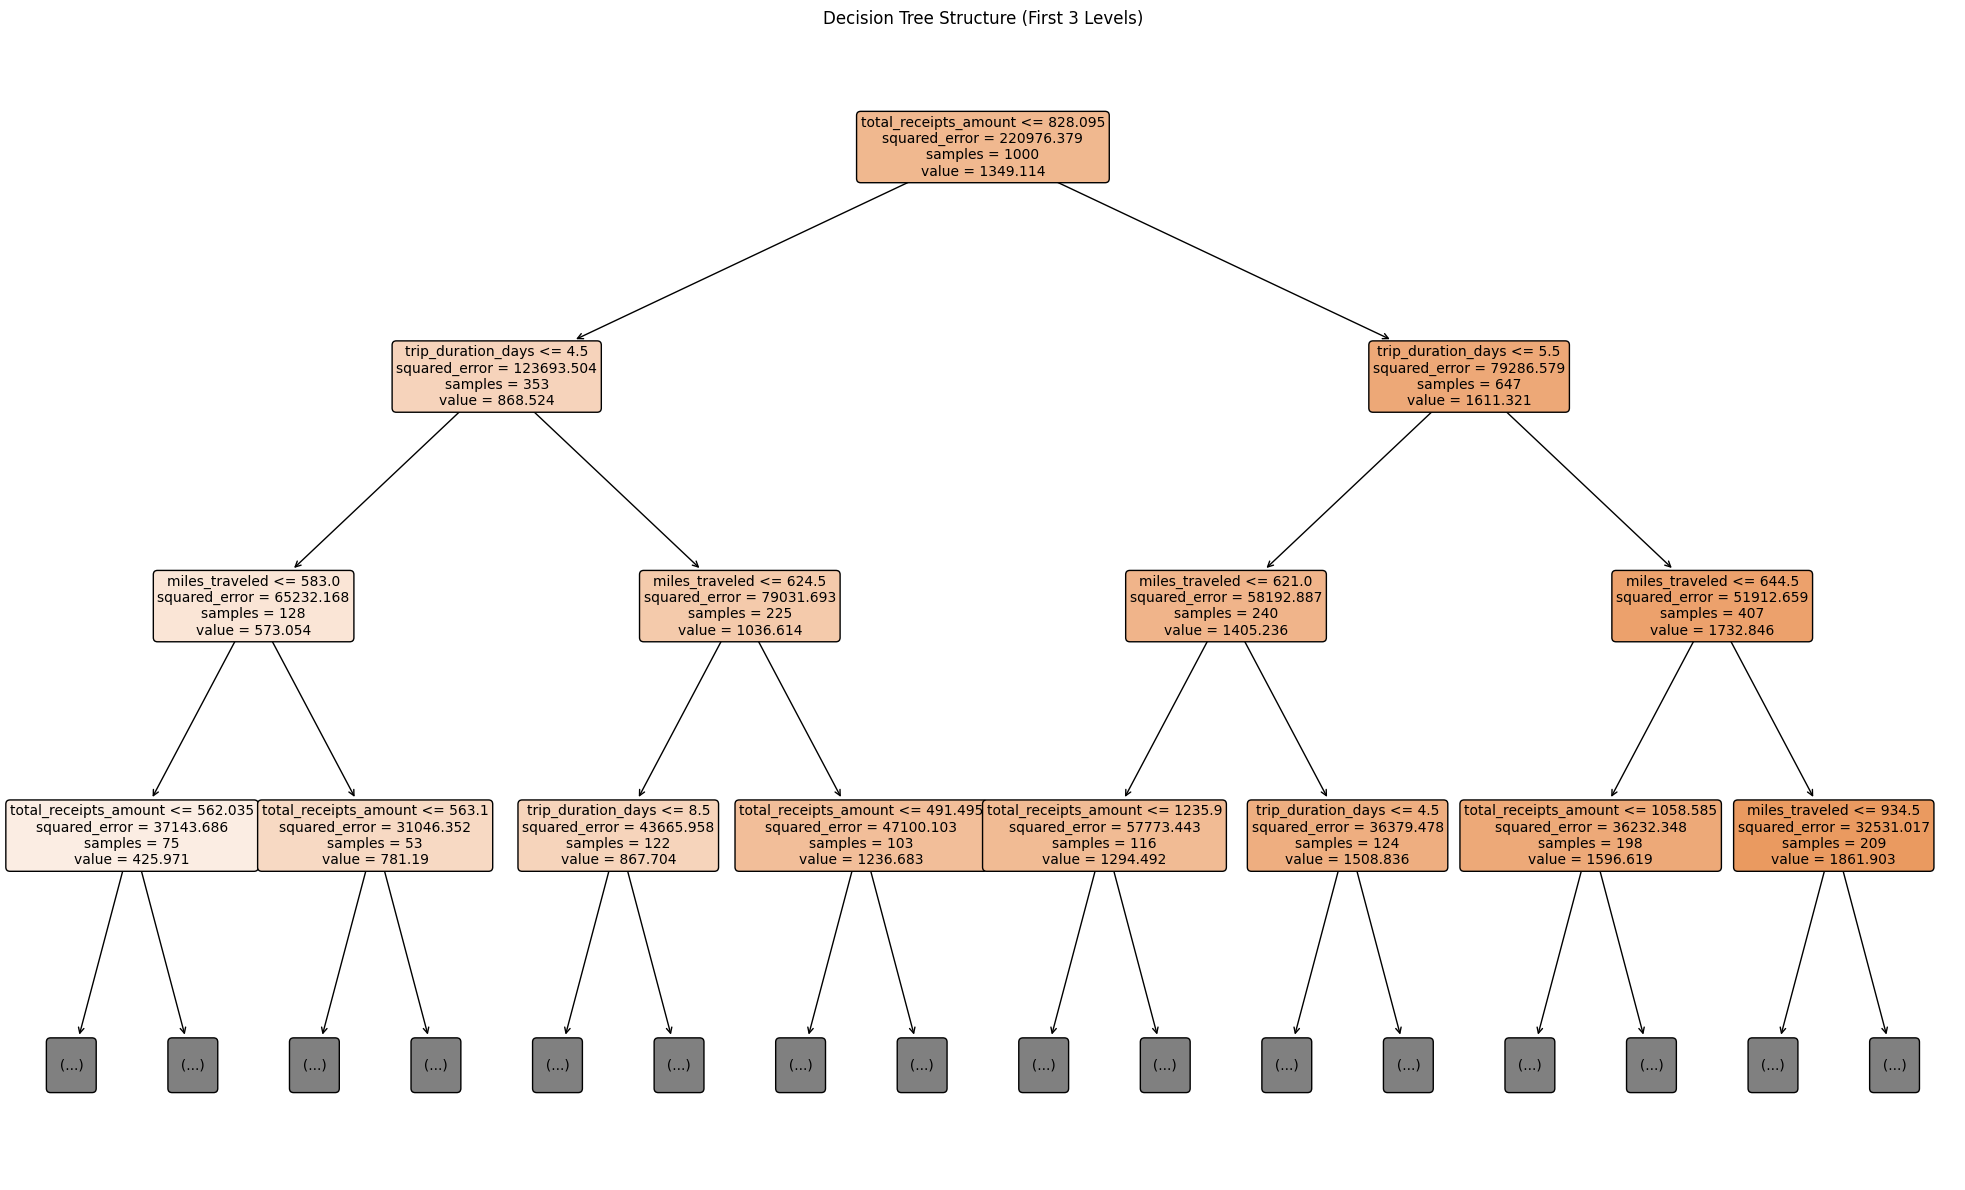


=== Top Decision Rules (by sample count) ===

Rule 1 (covers 3 samples):
  IF total_receipts_amount <= 828.10 AND trip_duration_days <= 4.50 AND miles_traveled <= 583.00 AND total_receipts_amount <= 562.04 AND trip_duration_days <= 1.50 AND miles_traveled <= 197.50 AND miles_traveled > 67.50 AND miles_traveled <= 140.50 AND total_receipts_amount <= 56.27
  THEN predicted_output = $179.03

Rule 2 (covers 3 samples):
  IF total_receipts_amount <= 828.10 AND trip_duration_days <= 4.50 AND miles_traveled <= 583.00 AND total_receipts_amount <= 562.04 AND trip_duration_days > 1.50 AND miles_traveled <= 203.50 AND trip_duration_days <= 2.50 AND miles_traveled <= 118.00
  THEN predicted_output = $214.10

Rule 3 (covers 3 samples):
  IF total_receipts_amount <= 828.10 AND trip_duration_days <= 4.50 AND miles_traveled <= 583.00 AND total_receipts_amount <= 562.04 AND trip_duration_days > 1.50 AND miles_traveled <= 203.50 AND trip_duration_days > 2.50 AND total_receipts_amount <= 394.01 AND mile

In [52]:
# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Visualize the decision tree (first few levels only)
plt.figure(figsize=(20, 12))
plot_tree(dt_model, 
          feature_names=list(X.columns),  # Convert Index to list
          max_depth=3,  # Only show first 3 levels for readability
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure (First 3 Levels)')
plt.tight_layout()
plt.show()

# Extract decision rules
def get_decision_rules(tree, feature_names, max_rules=20):
    """Extract human-readable decision rules from the tree."""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    
    rules = []
    
    def recurse(node, depth, condition=""):
        if tree_.feature[node] != -2:  # Not a leaf
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Left child (<=)
            left_condition = f"{condition} AND {name} <= {threshold:.2f}" if condition else f"{name} <= {threshold:.2f}"
            recurse(tree_.children_left[node], depth + 1, left_condition)
            
            # Right child (>)
            right_condition = f"{condition} AND {name} > {threshold:.2f}" if condition else f"{name} > {threshold:.2f}"
            recurse(tree_.children_right[node], depth + 1, right_condition)
        else:  # Leaf node
            value = tree_.value[node][0][0]
            samples = tree_.n_node_samples[node]
            rules.append({
                'condition': condition,
                'prediction': value,
                'samples': samples
            })
    
    recurse(0, 0)
    
    # Sort by number of samples (most common rules first)
    rules.sort(key=lambda x: x['samples'], reverse=True)
    
    return rules[:max_rules]

# Get and display decision rules
rules = get_decision_rules(dt_model, list(X.columns))  # Convert Index to list

print("\n=== Top Decision Rules (by sample count) ===")
for i, rule in enumerate(rules[:10], 1):
    print(f"\nRule {i} (covers {rule['samples']} samples):")
    print(f"  IF {rule['condition']}")
    print(f"  THEN predicted_output = ${rule['prediction']:.2f}")

# Analyze splits by feature
print("\n=== Key Split Points Analysis ===")
tree_ = dt_model.tree_
for i, feature_idx in enumerate(tree_.feature):
    if feature_idx != -2:  # Not a leaf
        feature_name = X.columns[feature_idx]
        threshold = tree_.threshold[i]
        samples = tree_.n_node_samples[i]
        if samples > 50:  # Only show splits with significant sample sizes
            print(f"Split on {feature_name} at {threshold:.2f} (covers {samples} samples)")


In [53]:
# Output the complete decision tree logic
import json

def extract_complete_tree_logic(model, feature_names):
    """Extract the complete decision tree structure with all nodes and paths"""
    tree_ = model.tree_
    
    def get_node_info(node_id, depth=0, path=""):
        """Recursively extract node information"""
        indent = "  " * depth
        
        if tree_.children_left[node_id] != tree_.children_right[node_id]:  # Not a leaf
            feature_idx = tree_.feature[node_id]
            feature_name = feature_names[feature_idx]
            threshold = tree_.threshold[node_id]
            samples = tree_.n_node_samples[node_id]
            
            node_info = {
                'node_id': int(node_id),
                'type': 'split',
                'feature': feature_name,
                'threshold': round(threshold, 2),
                'samples': int(samples),
                'depth': depth,
                'path': path,
                'left_child': None,
                'right_child': None
            }
            
            # Recursively get children
            left_path = f"{path} AND {feature_name} <= {threshold:.2f}" if path else f"{feature_name} <= {threshold:.2f}"
            right_path = f"{path} AND {feature_name} > {threshold:.2f}" if path else f"{feature_name} > {threshold:.2f}"
            
            node_info['left_child'] = get_node_info(tree_.children_left[node_id], depth + 1, left_path)
            node_info['right_child'] = get_node_info(tree_.children_right[node_id], depth + 1, right_path)
            
            return node_info
        else:  # Leaf node
            value = tree_.value[node_id][0][0]
            samples = tree_.n_node_samples[node_id]
            
            return {
                'node_id': int(node_id),
                'type': 'leaf',
                'prediction': round(value, 2),
                'samples': int(samples),
                'depth': depth,
                'path': path
            }
    
    return get_node_info(0)

# Extract complete tree structure
complete_tree = extract_complete_tree_logic(dt_model, list(X.columns))

# Convert rules to a more readable format for output
rules_output = []
for i, rule in enumerate(rules, 1):
    rules_output.append({
        'rule_number': i,
        'condition': rule['condition'],
        'predicted_output': round(rule['prediction'], 2),
        'sample_count': rule['samples'],
        'sample_percentage': round((rule['samples'] / len(X)) * 100, 2)
    })

# Save complete tree structure to JSON
with open('complete_decision_tree.json', 'w') as f:
    json.dump(complete_tree, f, indent=2, default=int)

# Save rules to JSON file
with open('decision_rules.json', 'w') as f:
    json.dump(rules_output, f, indent=2, default=int)

print(f"\n=== Decision Tree Output ===")
print(f"Complete tree structure saved to: complete_decision_tree.json")
print(f"Total rules extracted: {len(rules_output)}")
print(f"Rules saved to: decision_rules.json")

# Create a comprehensive text version with tree structure
def print_tree_structure(node, file_handle, depth=0):
    """Print tree structure in a readable format"""
    indent = "  " * depth
    
    if node['type'] == 'split':
        file_handle.write(f"{indent}Node {node['node_id']}: Split on {node['feature']} <= {node['threshold']}\n")
        file_handle.write(f"{indent}  Samples: {node['samples']}\n")
        file_handle.write(f"{indent}  Left branch (<=):\n")
        print_tree_structure(node['left_child'], file_handle, depth + 2)
        file_handle.write(f"{indent}  Right branch (>):\n")
        print_tree_structure(node['right_child'], file_handle, depth + 2)
    else:  # leaf
        file_handle.write(f"{indent}Leaf {node['node_id']}: Prediction = ${node['prediction']}\n")
        file_handle.write(f"{indent}  Samples: {node['samples']}\n")
        file_handle.write(f"{indent}  Path: {node['path']}\n")

# Create comprehensive text output
with open('decision_tree_complete.txt', 'w') as f:
    f.write("COMPLETE DECISION TREE ANALYSIS\n")
    f.write("=" * 50 + "\n\n")
    
    f.write("TREE STRUCTURE:\n")
    f.write("-" * 20 + "\n")
    print_tree_structure(complete_tree, f)
    
    f.write("\n\nDECISION RULES (Path-based):\n")
    f.write("=" * 50 + "\n\n")
    
    for rule in rules_output:
        f.write(f"Rule {rule['rule_number']} (covers {rule['sample_count']} samples, {rule['sample_percentage']}% of data):\n")
        f.write(f"  IF {rule['condition']}\n")
        f.write(f"  THEN predicted_output = ${rule['predicted_output']}\n\n")
    
    f.write("\nTREE STATISTICS:\n")
    f.write("-" * 20 + "\n")
    f.write(f"• Total nodes: {dt_model.tree_.node_count}\n")
    f.write(f"• Max depth: {dt_model.tree_.max_depth}\n")
    f.write(f"• Number of leaves: {dt_model.tree_.n_leaves}\n")
    f.write(f"• Number of features used: {len(set(dt_model.tree_.feature[dt_model.tree_.feature >= 0]))}\n")
    f.write(f"• Most common rule covers {rules_output[0]['sample_count']} samples ({rules_output[0]['sample_percentage']}%)\n")
    f.write(f"• Top 5 rules cover {sum(r['sample_count'] for r in rules_output[:5])} samples\n")
    f.write(f"• Rules with >1% coverage: {len([r for r in rules_output if r['sample_percentage'] > 1])}\n")

print("Complete tree structure saved to: decision_tree_complete.txt")

# Also create a Python implementation of the tree logic
with open('tree_implementation.py', 'w') as f:
    f.write("# Auto-generated decision tree implementation\n")
    f.write("# Based on the trained decision tree model\n\n")
    f.write("def calculate_reimbursement_tree(trip_duration_days, miles_traveled, total_receipts_amount):\n")
    f.write('    """\n')
    f.write('    Calculate reimbursement using decision tree logic\n')
    f.write('    \n')
    f.write('    Args:\n')
    f.write('        trip_duration_days: Number of days for the trip\n')
    f.write('        miles_traveled: Total miles traveled\n')
    f.write('        total_receipts_amount: Total amount of receipts\n')
    f.write('    \n')
    f.write('    Returns:\n')
    f.write('        float: Predicted reimbursement amount\n')
    f.write('    """\n')
    
    def generate_python_code(node, indent_level=1):
        """Generate Python code for the tree logic"""
        indent = "    " * indent_level
        
        if node['type'] == 'split':
            condition = f"{node['feature']} <= {node['threshold']}"
            code = f"{indent}if {condition}:\n"
            code += generate_python_code(node['left_child'], indent_level + 1)
            code += f"{indent}else:\n"
            code += generate_python_code(node['right_child'], indent_level + 1)
            return code
        else:  # leaf
            return f"{indent}return {node['prediction']}\n"
    
    f.write(generate_python_code(complete_tree))
    f.write("\n\n# Example usage:\n")
    f.write("# result = calculate_reimbursement_tree(2, 150, 200)\n")
    f.write("# print(f'Predicted reimbursement: ${result:.2f}')\n")

print("Python implementation saved to: tree_implementation.py")



=== Decision Tree Output ===
Complete tree structure saved to: complete_decision_tree.json
Total rules extracted: 20
Rules saved to: decision_rules.json
Complete tree structure saved to: decision_tree_complete.txt
Python implementation saved to: tree_implementation.py
